In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.2f}'.format

data = pd.read_csv('nobel_prize_data.csv')

print(f'Shape : {data.shape}')
data.head()

Shape : (962, 16)


,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Frédéric Passy,1822-05-20,Paris,France,France,Male,NaN,NaN,NaN,FRA
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,NaN,NaN,NaN,CHE


In [2]:
print(f'Duplicates? : {data.duplicated().values.any()}')
print(f'NaN values : {data.isna().values.any()}')
print(data.isna().sum().to_string())

Duplicates? : False
NaN values : True
year                       0
category                   0
prize                      0
motivation                88
prize_share                0
laureate_type              0
full_name                  0
birth_date                28
birth_city                31
birth_country             28
birth_country_current     28
sex                       28
organization_name        255
organization_city        255
organization_country     254
ISO                       28


In [3]:
col_subset = ['year', 'category', 'laureate_type', 'birth_date', 'full_name', 'organization_name']
data.loc[data.birth_date.isna()][col_subset]

,year,category,laureate_type,birth_date,full_name,organization_name
24,1904,Peace,Organization,NaN,Institut de droit international (Institute of ...,NaN
60,1910,Peace,Organization,NaN,Bureau international permanent de la Paix (Per...,NaN
89,1917,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
200,1938,Peace,Organization,NaN,Office international Nansen pour les Réfugiés ...,NaN
215,1944,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
237,1947,Peace,Organization,NaN,American Friends Service Committee (The Quakers),NaN
238,1947,Peace,Organization,NaN,Friends Service Council (The Quakers),NaN
283,1954,Peace,Organization,NaN,Office of the United Nations High Commissioner...,NaN
348,1963,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
349,1963,Peace,Organization,NaN,Ligue des Sociétés de la Croix-Rouge (League o...,NaN


In [4]:
data.birth_date = pd.to_datetime(data.birth_date)
seperated_values = data.prize_share.str.split('/', expand=True)

numerator = pd.to_numeric(seperated_values[0])
denominator = pd.to_numeric(seperated_values[1])

data['share_pct'] = numerator / denominator

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    object        
 2   prize                  962 non-null    object        
 3   motivation             874 non-null    object        
 4   prize_share            962 non-null    object        
 5   laureate_type          962 non-null    object        
 6   full_name              962 non-null    object        
 7   birth_date             934 non-null    datetime64[ns]
 8   birth_city             931 non-null    object        
 9   birth_country          934 non-null    object        
 10  birth_country_current  934 non-null    object        
 11  sex                    934 non-null    object        
 12  organization_name      707 non-null    object        
 13  organ

In [6]:
biology = data.sex.value_counts()
fig = px.pie(labels = biology.index, values = biology.values, title = 'Percentage of M v/s F Winners', names = biology.index, hole = 0.4)

fig.update_traces(textposition = 'inside', textfont_size = 15, textinfo = 'percent')

fig.show()

In [7]:
data[data.sex == 'Female'].sort_values('year', ascending=True)[:3]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
18,1903,Physics,The Nobel Prize in Physics 1903,"""in recognition of the extraordinary services ...",1/4,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,Russian Empire (Poland),Poland,Female,NaN,NaN,NaN,POL,0.25
29,1905,Peace,The Nobel Peace Prize 1905,NaN,1/1,Individual,"Baroness Bertha Sophie Felicita von Suttner, n...",1843-06-09,Prague,Austrian Empire (Czech Republic),Czech Republic,Female,NaN,NaN,NaN,CZE,1.00
51,1909,Literature,The Nobel Prize in Literature 1909,"""in appreciation of the lofty idealism, vivid ...",1/1,Individual,Selma Ottilia Lovisa Lagerlöf,1858-11-20,Mårbacka,Sweden,Sweden,Female,NaN,NaN,NaN,SWE,1.00


In [8]:
is_winner = data.duplicated(subset = ['full_name'], keep = False)
multiple_winners = data[is_winner]

print(f'Laureates awarded the prize more than once : {multiple_winners.full_name.unique()}')

col_subset = ['year', 'category', 'laureate_type', 'full_name']
multiple_winners[col_subset]

Laureates awarded the prize more than once : ['Marie Curie, née Sklodowska'
 'Comité international de la Croix Rouge (International Committee of the Red Cross)'
 'Linus Carl Pauling'
 'Office of the United Nations High Commissioner for Refugees (UNHCR)'
 'John Bardeen' 'Frederick Sanger']


,year,category,laureate_type,full_name
18,1903,Physics,Individual,"Marie Curie, née Sklodowska"
62,1911,Chemistry,Individual,"Marie Curie, née Sklodowska"
89,1917,Peace,Organization,Comité international de la Croix Rouge (Intern...
215,1944,Peace,Organization,Comité international de la Croix Rouge (Intern...
278,1954,Chemistry,Individual,Linus Carl Pauling
283,1954,Peace,Organization,Office of the United Nations High Commissioner...
297,1956,Physics,Individual,John Bardeen
306,1958,Chemistry,Individual,Frederick Sanger
340,1962,Peace,Individual,Linus Carl Pauling
348,1963,Peace,Organization,Comité international de la Croix Rouge (Intern...


In [9]:
print(f'Categories : {data.category.nunique()}')

prizes_per_category = data.category.value_counts()
v_bar = px.bar(x = prizes_per_category.index, y = prizes_per_category.values, color = prizes_per_category.values, color_continuous_scale = 'Aggrnyl', title = 'Prizes Awarded per Category')

v_bar.update_layout(xaxis_title = 'Nobel Prize Category', yaxis_title = 'Total Prizes', coloraxis_showscale = False)

v_bar.show()

Categories : 6


In [10]:
data[data.category == 'Economics'].sort_values('year')[:3]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
393,1969,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Jan Tinbergen,1903-04-12,the Hague,Netherlands,Netherlands,Male,The Netherlands School of Economics,Rotterdam,Netherlands,NLD,0.50
394,1969,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Ragnar Frisch,1895-03-03,Oslo,Norway,Norway,Male,University of Oslo,Oslo,Norway,NOR,0.50
402,1970,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for the scientific work through which he has ...",1/1,Individual,Paul A. Samuelson,1915-05-15,"Gary, IN",United States of America,United States of America,Male,Massachusetts Institute of Technology (MIT),"Cambridge, MA",United States of America,USA,1.00


In [11]:
gender_category = data.groupby(['category', 'sex'], as_index=False).agg({'prize': pd.Series.count})
gender_category.sort_values('prize', ascending=False, inplace=True)

gender_category

,category,sex,prize
11,Physics,Male,212
7,Medicine,Male,210
1,Chemistry,Male,179
5,Literature,Male,101
9,Peace,Male,90
3,Economics,Male,84
8,Peace,Female,17
4,Literature,Female,16
6,Medicine,Female,12
0,Chemistry,Female,7


In [12]:
v_bar_split = px.bar(x = gender_category.category, y = gender_category.prize, color = gender_category.sex, title = 'Prizes Awarded per Category Gender Split')

v_bar_split.update_layout(xaxis_title = 'Nobel Prize Category', yaxis_title = 'Total Prizes')

v_bar_split.show()

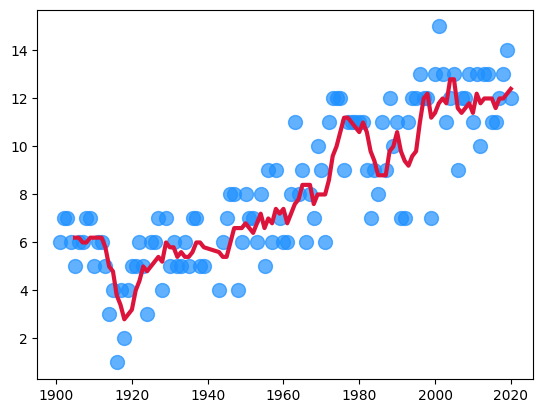

In [13]:
prize_per_year = data.groupby(by='year').count().prize
moving_average = prize_per_year.rolling(window=5).mean()

plt.scatter(x = prize_per_year.index, y = prize_per_year.values, c = 'dodgerblue', alpha = 0.7, s = 100)

plt.plot(prize_per_year.index, moving_average.values, c = 'crimson', linewidth = 3)

plt.show()

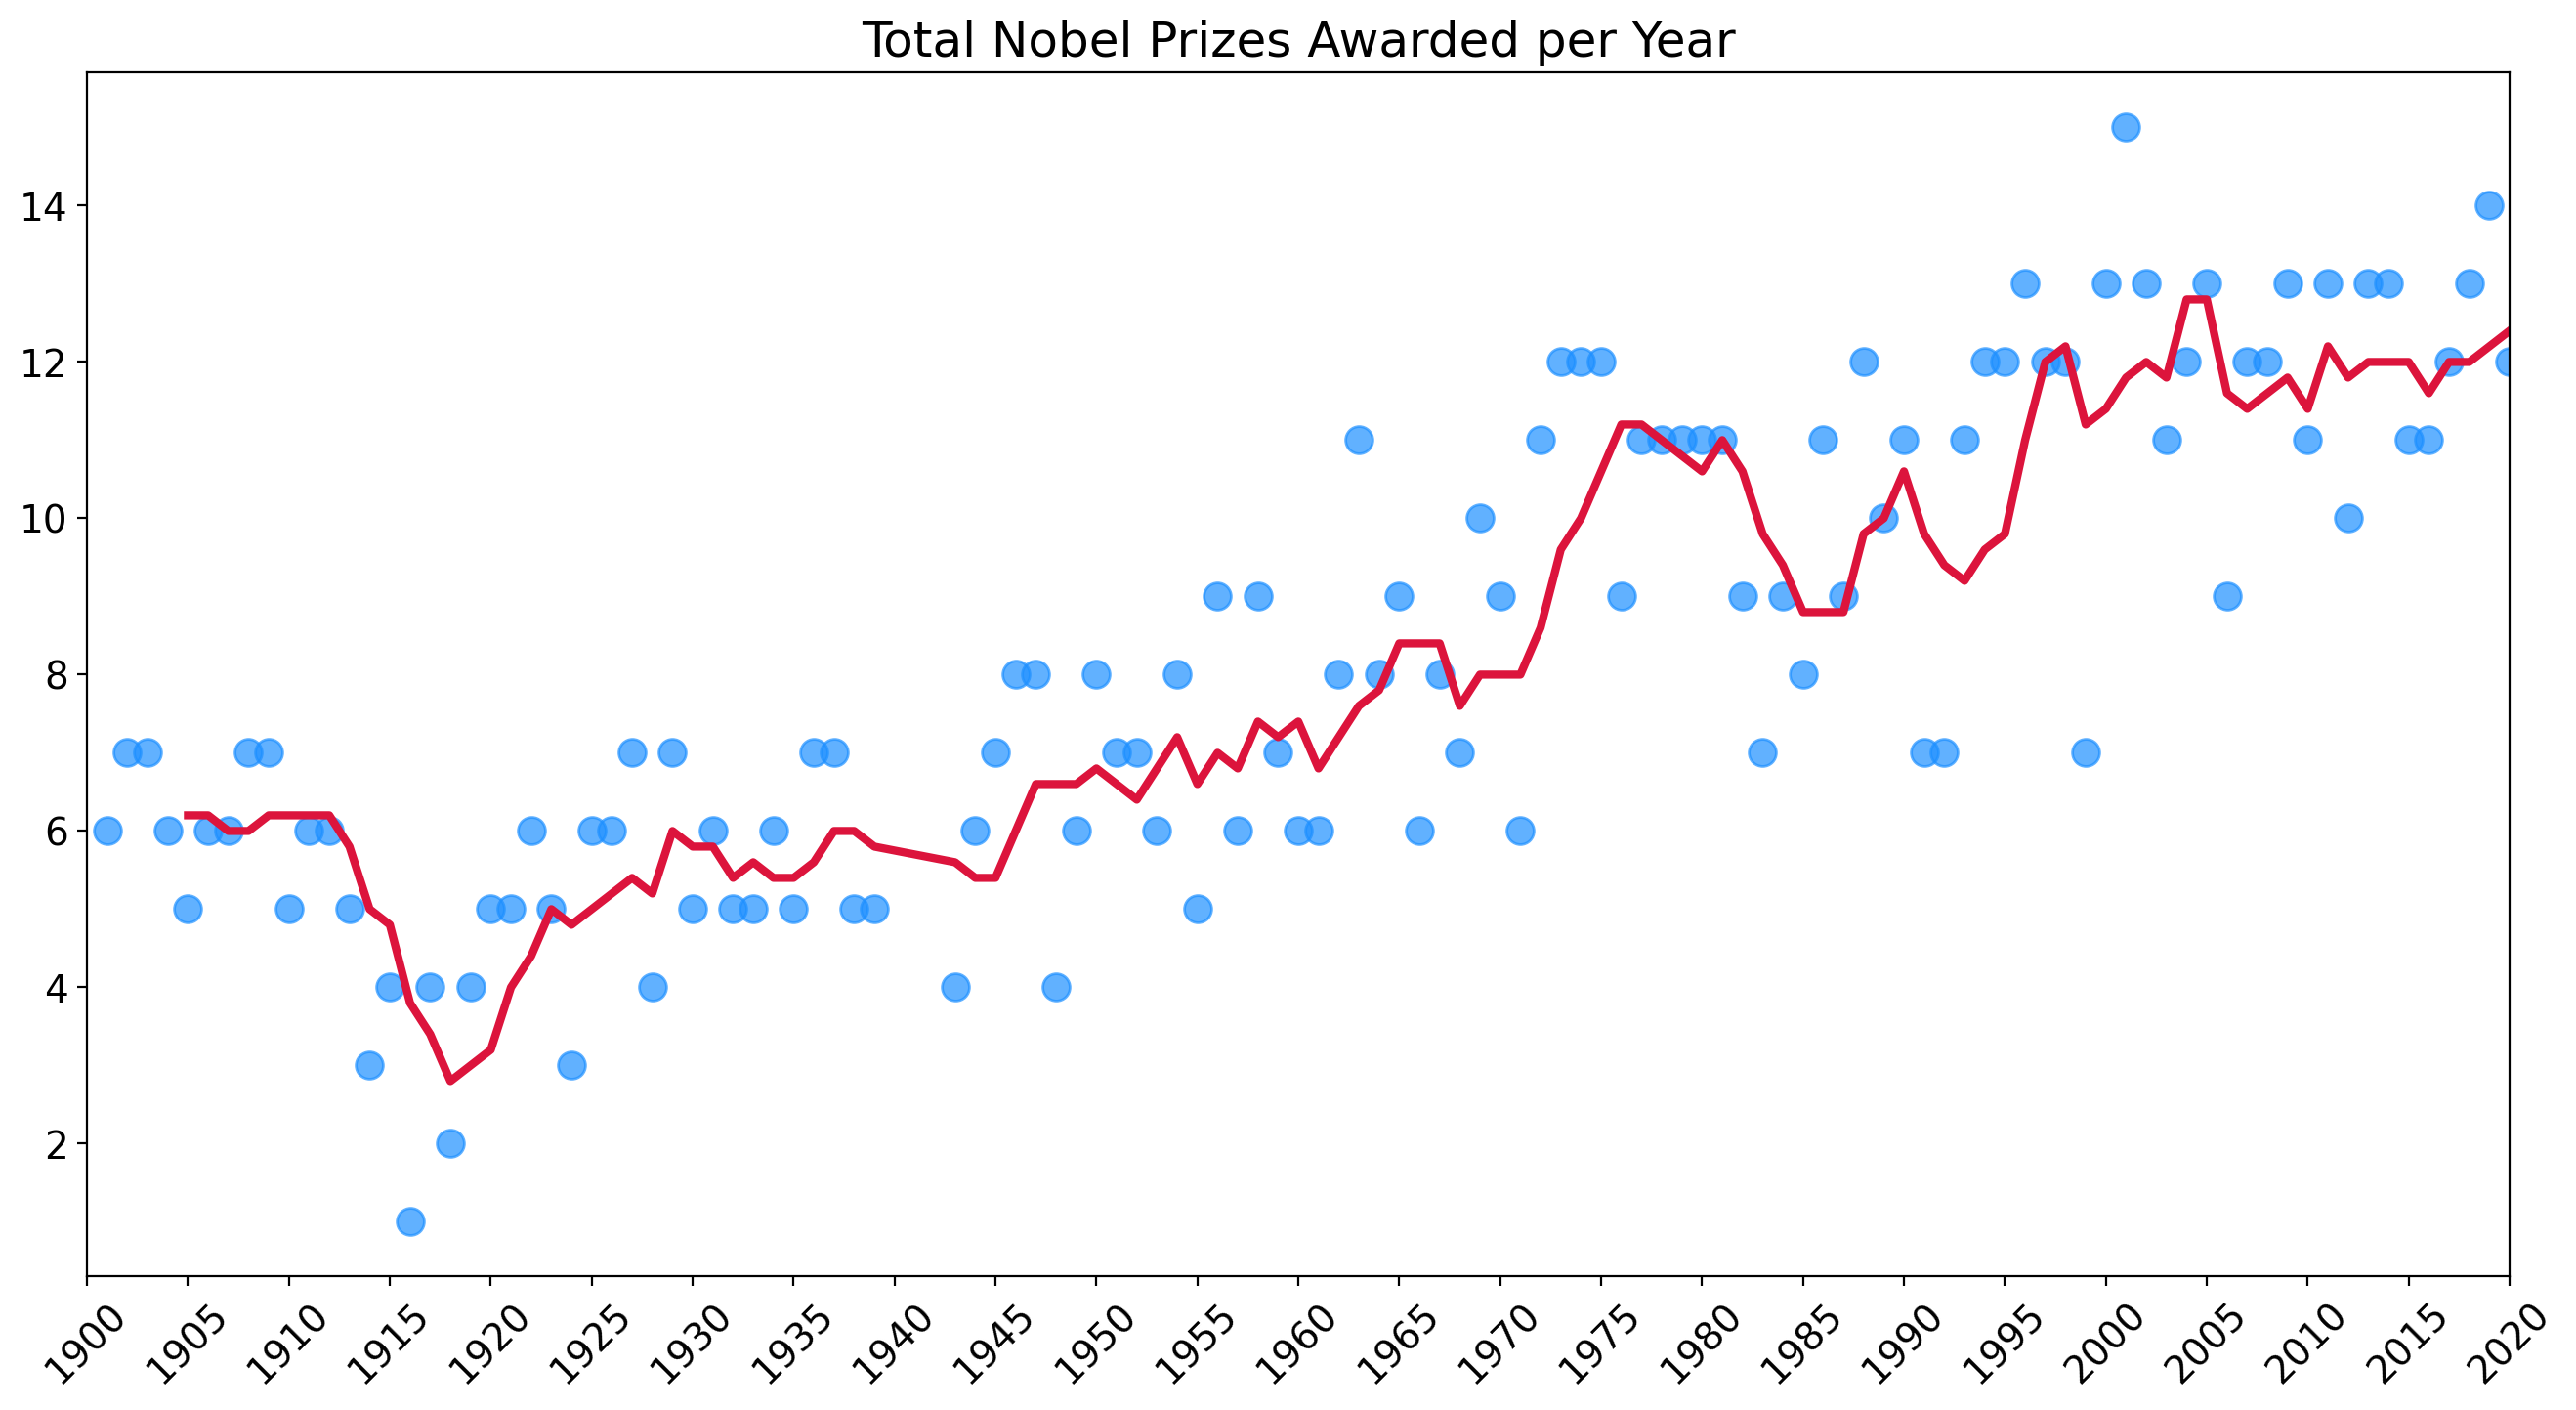

In [14]:
plt.figure(figsize=(16, 8), dpi = 200)
plt.title('Total Nobel Prizes Awarded per Year', fontsize = 18)
plt.yticks(fontsize = 14)
plt.xticks(ticks = np.arange(1900, 2021, step = 5), fontsize = 14, rotation = 45)

ax_prize = plt.gca()
ax_prize.set_xlim(1900, 2020)

ax_prize.scatter(x = prize_per_year.index, y = prize_per_year.values, c = 'dodgerblue', alpha = 0.7, s = 100)

ax_prize.plot(prize_per_year.index, moving_average.values, c = 'crimson', linewidth = 3)

plt.show()

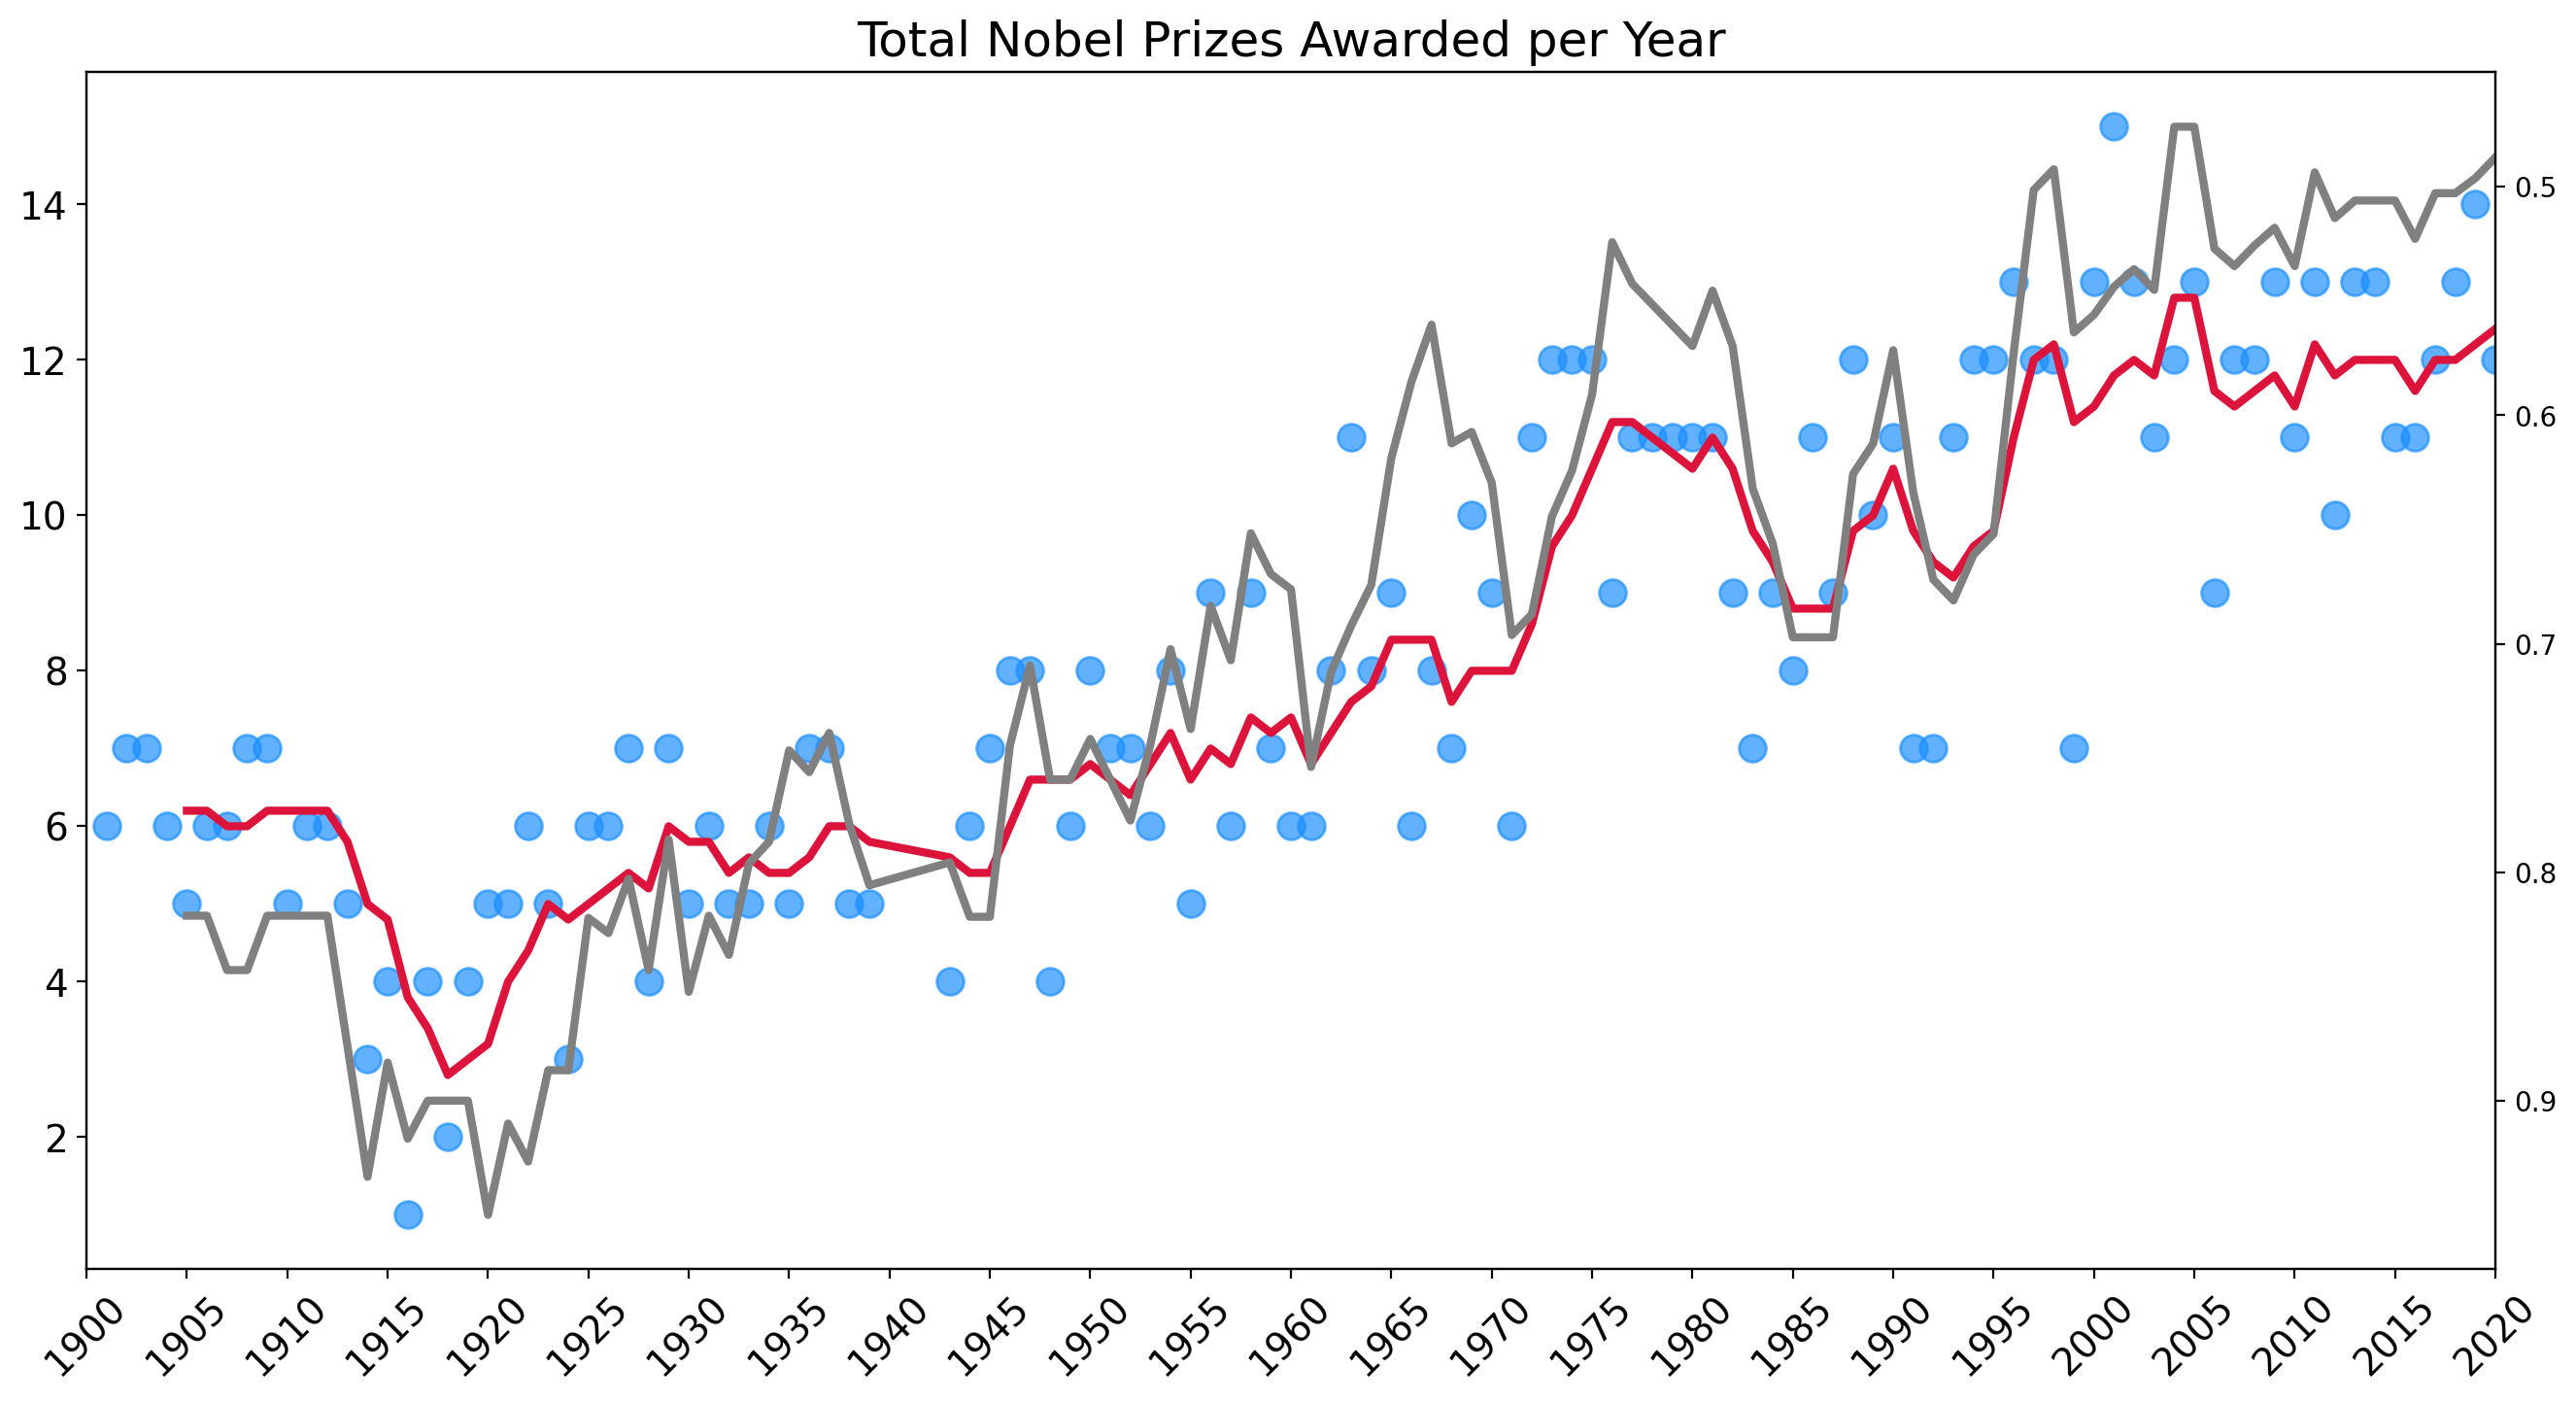

In [15]:
yearly_avg_share = data.groupby(by='year').agg({'share_pct': pd.Series.mean})
share_moving_average = yearly_avg_share.rolling(window=5).mean()

plt.figure(figsize=(16, 8), dpi = 200)
plt.title('Total Nobel Prizes Awarded per Year', fontsize = 18)
plt.yticks(fontsize = 14)
plt.xticks(ticks = np.arange(1900, 2021, step = 5), fontsize = 14, rotation = 45)

ax_prize = plt.gca()
ax_share = ax_prize.twinx()
ax_prize.set_xlim(1900, 2020)
ax_share.invert_yaxis()

ax_prize.scatter(x = prize_per_year.index, y = prize_per_year.values, c = 'dodgerblue', alpha = 0.7, s = 100)

ax_prize.plot(prize_per_year.index, moving_average.values, c = 'crimson', linewidth = 3)
ax_share.plot(prize_per_year.index, share_moving_average.values, c = 'grey', linewidth = 3)

plt.show()

In [16]:
top_countries = data.groupby(['birth_country_current'], as_index=False).agg({'prize': pd.Series.count})

top_countries.sort_values(by='prize', ascending=True, inplace=True)
top20_countries = top_countries.tail(20).reset_index(drop=True)

h_bar = px.bar(x = top20_countries.prize, y = top20_countries.birth_country_current, orientation = 'h', color = top20_countries.prize, color_continuous_scale = 'Viridis', title = 'Top 20 Countries by Total Prizes')

h_bar.update_layout(xaxis_title = 'Total Prizes', yaxis_title = 'Country', coloraxis_showscale = False)

h_bar.show()

In [17]:
countries = data.groupby(['birth_country_current', 'ISO'], as_index=False).agg({'prize': pd.Series.count})
countries.sort_values('prize', ascending=False)

world_map = px.choropleth(countries, locations = 'ISO', color = 'prize', hover_name = 'birth_country_current', color_continuous_scale = px.colors.sequential.matter)

world_map.update_layout(coloraxis_showscale = True)

world_map.show()

In [18]:
category_per_country = data.groupby(['birth_country_current', 'category'], as_index=False).agg({'prize': pd.Series.count})
category_per_country.sort_values(by='prize', ascending=False, inplace=True)

merged_data = pd.merge(category_per_country, top20_countries, on='birth_country_current')

merged_data.columns = ['birth_country_current', 'category', 'cat_prize', 'total_prize']
merged_data.sort_values(by='total_prize', inplace=True)

merge_bar = px.bar(x = merged_data.cat_prize, y = merged_data.birth_country_current, color = merged_data.category, orientation = 'h', title = 'Top 20 countries by Total Prizes')

merge_bar.update_layout(xaxis_title = 'Total Prizes', yaxis_title = 'Country')

merge_bar.show()

In [19]:
prize_by_year = data.groupby(['birth_country_current', 'year']).size().reset_index(name='prize')
prize_by_year = prize_by_year.sort_values(['birth_country_current', 'year'])

prize_by_year['cumulative_prize'] = prize_by_year.groupby('birth_country_current')['prize'].cumsum()

l_chart = px.line(prize_by_year, x = 'year', y = 'cumulative_prize', color = 'birth_country_current', hover_name = 'birth_country_current')

l_chart.update_layout(xaxis_title = 'Year', yaxis_title = 'Total Cumulative Prizes')

l_chart.show()

In [20]:
top20_orgs = data.organization_name.value_counts()[:20]
top20_orgs.sort_values(ascending=True, inplace=True)

org_bar = px.bar(x = top20_orgs.values, y = top20_orgs.index, orientation = 'h', color = top20_orgs.values, color_continuous_scale = px.colors.sequential.haline, title = 'Top 20 Research Institutions by Total Prizes')

org_bar.update_layout(xaxis_title = 'Total Prizes', yaxis_title = 'Institution', coloraxis_showscale = False)

org_bar.show()